## 鸢尾花种类预测————ML分类模型应用实战
鸢尾花数据集是一个经典的机器学习数据集，用于分类任务。数据集共150行（150个样本）+6列（1列id+4列特征+1列标签）。
鸢尾花的种类包括sentosa、versicolor、virginica，特征包括花萼长度、花萼宽度、花瓣长度、花瓣宽度。

### （一）数据读取与数据探索

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [4]:
# 读取数据 查看前五行
df = pd.read_csv("Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.shape

(150, 6)

In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [8]:
df.drop('Id',axis = 1, inplace = True)

In [9]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### （二）数据可视化
通过散点图、直方图、小提琴图、热力图等可视化方法，可以快速了解特征之间的相互关系，为后续的特征选择和模型建立铺垫基础。

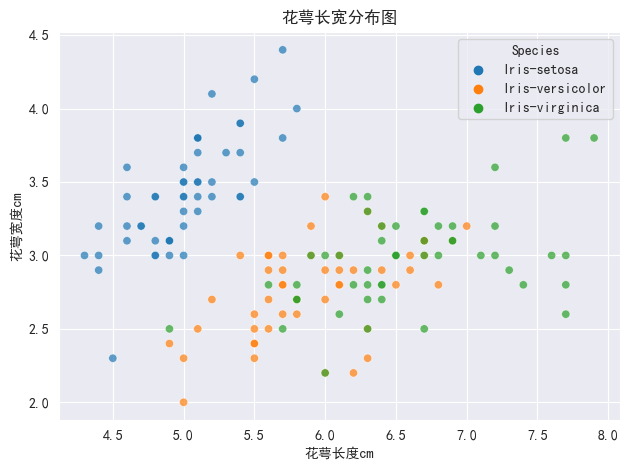

In [14]:
# 画各类花的花萼长宽分布图
sns.set_style('darkgrid')
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 系统黑体

sns.scatterplot(
    data = df,
    hue = 'Species',
    x = 'SepalLengthCm',
    y = 'SepalWidthCm',
    alpha=0.7  # 调整透明度
)

plt.title('花萼长宽分布图')
plt.xlabel('花萼长度cm')
plt.ylabel('花萼宽度cm')
plt.tight_layout() # 自动调整位置
plt.show()

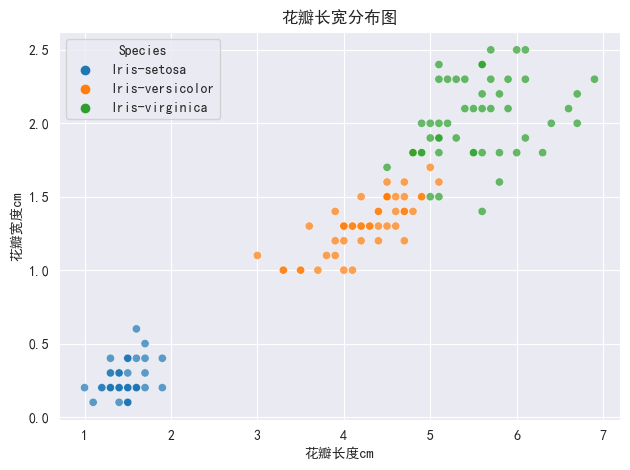

In [16]:
# 画各类花的花瓣长宽分布图
sns.set_style('darkgrid')
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 系统黑体

sns.scatterplot(
    data = df,
    hue = 'Species',
    x = 'PetalLengthCm',
    y = 'PetalWidthCm',
    alpha=0.7  # 调整透明度
)

plt.title('花瓣长宽分布图')
plt.xlabel('花瓣长度cm')
plt.ylabel('花瓣宽度cm')
plt.tight_layout() # 自动调整位置
plt.show()

如上图所示，相比于花萼而言，通过花瓣的特征更能区分不同种类的鸢尾花，因此可以考虑验证使用花瓣与使用花萼数据训练分类模型的准确率。

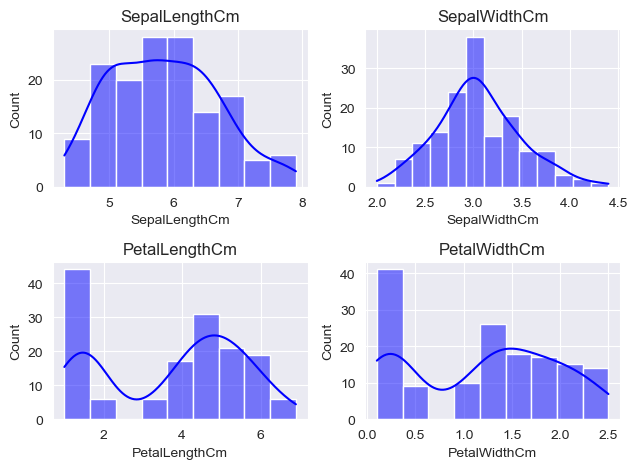

In [20]:
# 绘制花萼和花瓣长宽的直方图
sns.set_style('darkgrid')

columns = df.select_dtypes(include = [np.number]).columns.tolist()

for i , col in enumerate(columns):
    plt.subplot(2, 2, i+1) # 2*2网格中创建子图

    sns.histplot(
        data = df[col],
        kde = True,
        color = 'blue'
    )
    plt.title(col)

plt.tight_layout()
plt.show()

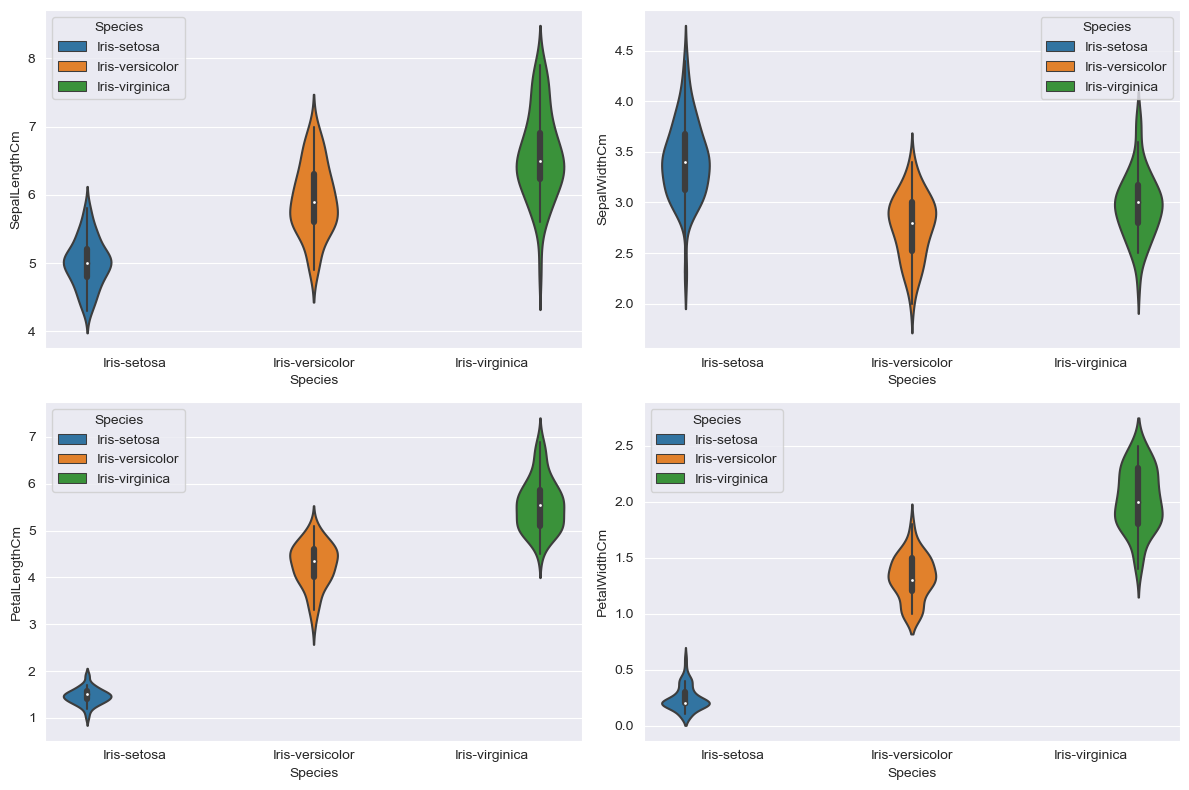

In [27]:
# 绘制小提琴图
# 相比箱线图 小提琴图还可以看密度分布曲线

sns.set_style('darkgrid')
plt.figure(figsize = (12,8))
columns = df.select_dtypes(include = [np.number]).columns.tolist()

for i , col in enumerate(columns):
    plt.subplot(2, 2, i+1) # 2*2网格中创建子图

    sns.violinplot(
        data = df,
        hue = 'Species',
        x = 'Species',
        y = col
    )
    plt.xlabel('Species')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### （三）模型训练

In [29]:
# 使用分类算法建立模型
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [31]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

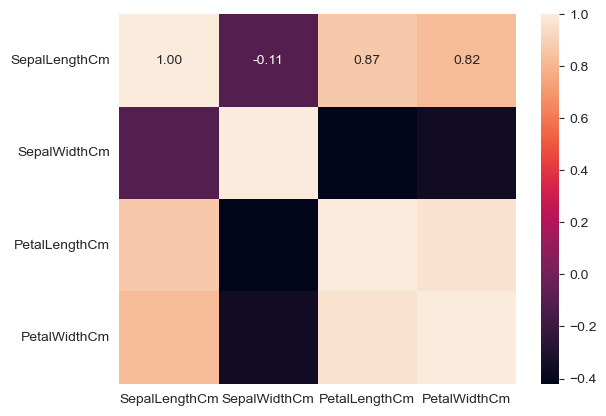

In [45]:
# 查看特征相关性

sns.heatmap(
    data = df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']].corr(),
    annot = True,
    fmt = ".2f"
)
plt.show()

可以看出花萼的长宽之间的相关度较低，花瓣的长宽高度相关。（但为什么只显示了第一行的数据？？

划分训练集与测试集，将数据集分为训练集（70%）和验证集（30%）

In [46]:
train,test = train_test_split(df,test_size = 0.3)
print(train.shape)
print(test.shape)

(105, 5)
(45, 5)


In [52]:
X_train = train[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
y_train = train['Species']

In [53]:
X_train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
31,5.4,3.4,1.5,0.4
12,4.8,3.0,1.4,0.1
16,5.4,3.9,1.3,0.4
84,5.4,3.0,4.5,1.5
92,5.8,2.6,4.0,1.2


In [54]:
y_train.head()

31        Iris-setosa
12        Iris-setosa
16        Iris-setosa
84    Iris-versicolor
92    Iris-versicolor
Name: Species, dtype: object

In [55]:
X_test = test[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
y_test = test['Species']

In [56]:
X_test.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
78,6.0,2.9,4.5,1.5
71,6.1,2.8,4.0,1.3
76,6.8,2.8,4.8,1.4
116,6.5,3.0,5.5,1.8


In [57]:
y_test.head()

0          Iris-setosa
78     Iris-versicolor
71     Iris-versicolor
76     Iris-versicolor
116     Iris-virginica
Name: Species, dtype: object

模型训练，依次检验SVM、决策树、随机森林、逻辑回归、KNN等模型的准确率。
先使用花萼长宽+花瓣长宽四个特征进行模型训练。

In [59]:
# 支持向量机SVM
model = svm.SVC()
model.fit(X_train,y_train)
prediction = model.predict(X_test)
print("The accuracy of svm is:",metrics.accuracy_score(prediction,y_test))

The accuracy of svm is: 0.9555555555555556


In [63]:
# 决策树
model = DecisionTreeClassifier()
model.fit(X_train,y_train)
prediction = model.predict(X_test)
print("The accuracy of DT is:",metrics.accuracy_score(prediction,y_test))

The accuracy of DT is: 0.9777777777777777


In [64]:
# 逻辑回归
model = LogisticRegression()
model.fit(X_train,y_train)
prediction = model.predict(X_test)
print("The accuracy of LogisticRegression is:",metrics.accuracy_score(prediction,y_test))

The accuracy of LogisticRegression is: 0.9555555555555556


In [105]:
# 随机森林
model = RandomForestClassifier()
model.fit(X_train,y_train)
prediction = model.predict(X_test)
print("The accuracy of RandomForestClassifier is:",metrics.accuracy_score(prediction,y_test))

The accuracy of RandomForestClassifier is: 0.9555555555555556


In [82]:
# KNN
model = KNeighborsClassifier(n_neighbors = 5)
model.fit(X_train,y_train)
prediction = model.predict(X_test)
print("The accuracy of KNN is:",metrics.accuracy_score(prediction,y_test))

The accuracy of KNN is: 0.9777777777777777


调整KNN中n_neighbors参数的数值（选取周围k个邻近点），用可视化的方法观察模型准确率的变化。

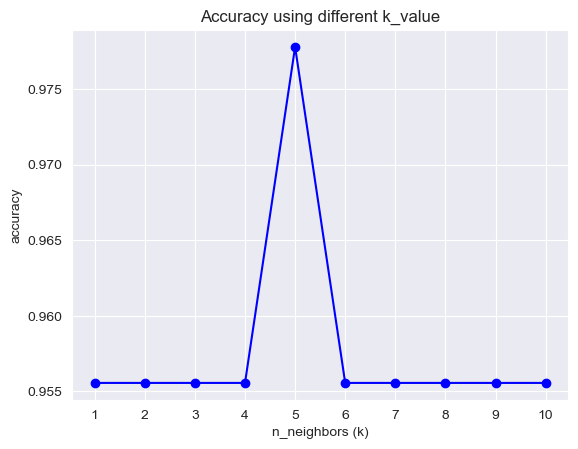

In [86]:
# 调整参数 结果可视化
# 初始化存储准确率的列表
accuracies = []
k_values = list(range(1, 11))  # k 的取值：1到10

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    acc = metrics.accuracy_score(y_test, prediction)
    accuracies.append(acc)  # 将准确率添加到列表

plt.plot(k_values, accuracies, marker='o', color='b')
plt.title("Accuracy using different k_value")
plt.xlabel("n_neighbors (k)")
plt.ylabel("accuracy")
plt.xticks(k_values)  # 确保 x 轴刻度显示所有 k 值
plt.show()

下面，分别使用花萼数据或花瓣数据来训练模型

In [87]:
# 花萼
sepal = df[['SepalLengthCm','SepalWidthCm','Species']]
# 花瓣
petal = df[['PetalLengthCm','PetalWidthCm','Species']]

In [88]:
sepal.head(2)

,SepalLengthCm,SepalWidthCm,Species
0,5.1,3.5,Iris-setosa
1,4.9,3.0,Iris-setosa


In [89]:
petal.head(2)

,PetalLengthCm,PetalWidthCm,Species
0,1.4,0.2,Iris-setosa
1,1.4,0.2,Iris-setosa


In [90]:
# 划分训练集和测试集
# 花萼数据
sepal_train, sepal_test = train_test_split(sepal,test_size = 0.3,random_state = 42)
X_train_s = sepal_train[['SepalLengthCm','SepalWidthCm']]
y_train_s = sepal_train['Species']
X_test_s = sepal_test[['SepalLengthCm','SepalWidthCm']]
y_test_s = sepal_test['Species']

# 花瓣数据
petal_train, petal_test = train_test_split(petal,test_size = 0.3,random_state = 42)
X_train_p = petal_train[['PetalLengthCm','PetalWidthCm']]
y_train_p = petal_train['Species']
X_test_p = petal_test[['PetalLengthCm','PetalWidthCm']]
y_test_p = petal_test['Species']

In [91]:
X_train_s.head(2)

,SepalLengthCm,SepalWidthCm
81,5.5,2.4
133,6.3,2.8


In [92]:
y_train_s.head(2)

81     Iris-versicolor
133     Iris-virginica
Name: Species, dtype: object

In [93]:
X_train_p.head(2)

,PetalLengthCm,PetalWidthCm
81,3.7,1.0
133,5.1,1.5


In [94]:
y_train_p.head(2)

81     Iris-versicolor
133     Iris-virginica
Name: Species, dtype: object

In [96]:
# 支持向量机SVM
model = svm.SVC()
model.fit(X_train_s,y_train_s)
prediction = model.predict(X_test_s)
print("The accuracy of svm using sepal:",metrics.accuracy_score(prediction,y_test_s))

model = svm.SVC()
model.fit(X_train_p,y_train_p)
prediction = model.predict(X_test_p)
print("The accuracy of svm using petal:",metrics.accuracy_score(prediction,y_test_p))

The accuracy of svm using sepal: 0.8
The accuracy of svm using petal: 1.0


In [97]:
# 决策树
model = DecisionTreeClassifier()
model.fit(X_train_s,y_train_s)
prediction = model.predict(X_test_s)
print("The accuracy of DecisionTreeClassifier using sepal:",metrics.accuracy_score(prediction,y_test_s))

model = DecisionTreeClassifier()
model.fit(X_train_p,y_train_p)
prediction = model.predict(X_test_p)
print("The accuracy of DecisionTreeClassifier using petal:",metrics.accuracy_score(prediction,y_test_p))

The accuracy of DecisionTreeClassifier using sepal: 0.6666666666666666
The accuracy of DecisionTreeClassifier using petal: 1.0


In [99]:
# 随机森林
model = RandomForestClassifier()
model.fit(X_train_s,y_train_s)
prediction = model.predict(X_test_s)
print("The accuracy of RandomForest using sepal:",metrics.accuracy_score(prediction,y_test_s))

model = RandomForestClassifier()
model.fit(X_train_p,y_train_p)
prediction = model.predict(X_test_p)
print("The accuracy of RandomForest using petal:",metrics.accuracy_score(prediction,y_test_p))

The accuracy of RandomForest using sepal: 0.7555555555555555
The accuracy of RandomForest using petal: 1.0


In [100]:
# 逻辑回归
model = LogisticRegression()
model.fit(X_train_s,y_train_s)
prediction = model.predict(X_test_s)
print("The accuracy of LogisticRegression using sepal:",metrics.accuracy_score(prediction,y_test_s))

model = LogisticRegression()
model.fit(X_train_p,y_train_p)
prediction = model.predict(X_test_p)
print("The accuracy of LogisticRegression using petal:",metrics.accuracy_score(prediction,y_test_p))

The accuracy of LogisticRegression using sepal: 0.8222222222222222
The accuracy of LogisticRegression using petal: 1.0


In [104]:
# KNN
model = KNeighborsClassifier()
model.fit(X_train_s,y_train_s)
prediction = model.predict(X_test_s)
print("The accuracy of KNeighborsClassifier using sepal:",metrics.accuracy_score(prediction,y_test_s))

model = KNeighborsClassifier()
model.fit(X_train_p,y_train_p)
prediction = model.predict(X_test_p)
print("The accuracy of KNeighborsClassifier using petal:",metrics.accuracy_score(prediction,y_test_p))

The accuracy of KNeighborsClassifier using sepal: 0.8
The accuracy of KNeighborsClassifier using petal: 1.0


可以看出，使用花瓣长宽训练得到的模型准确率远高于使用花萼数据的准确率。因此，用花瓣的长宽作为特征输入，预测鸢尾花的种类即可。

绘制混淆矩阵，将准确率可视化：

混淆矩阵数据:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


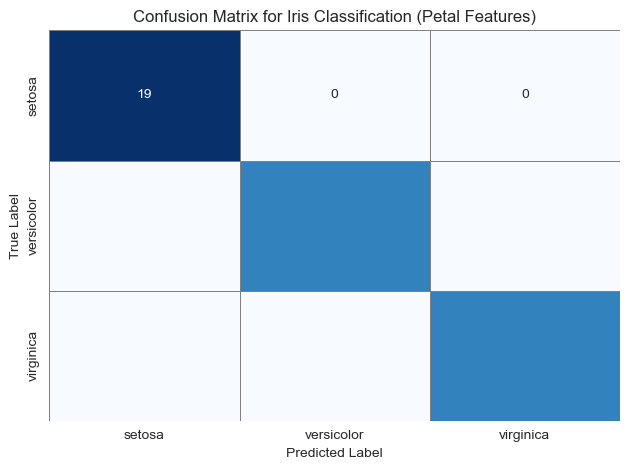

In [116]:
model = KNeighborsClassifier()
model.fit(X_train_p, y_train_p)
prediction = model.predict(X_test_p)
from sklearn.metrics import confusion_matrix

# 计算混淆矩阵
cm = confusion_matrix(y_test_p, prediction)
print("混淆矩阵数据:\n", cm)

# 转换为 DataFrame 并添加标签（假设类别为 ['setosa', 'versicolor', 'virginica']）
class_names = ['setosa', 'versicolor', 'virginica']
cm_df = pd.DataFrame(cm, 
                     index=class_names, 
                     columns=class_names
                    )

# 绘制热力图
sns.heatmap(cm_df, 
            annot=True, 
            fmt="d", 
            cmap="Blues",
            cbar=False,
            linewidths=0.6,
            linecolor='grey')
plt.title("Confusion Matrix for Iris Classification (Petal Features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=0) # 调整标签方向
plt.yticks(rotation=90)
plt.tight_layout()
plt.show()

计算精确率、召回率和F1分数，获得分类结果报告

In [118]:
from sklearn.metrics import classification_report

model = KNeighborsClassifier()
model.fit(X_train_p, y_train_p)
prediction = model.predict(X_test_p)
# 获取详细报告（支持多分类）
report = classification_report(y_test_p, prediction, target_names=['setosa', 'versicolor', 'virginica'])
print(report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

